# Object Extraction from Background using Thresholding

**Goal:** Extract foreground objects from a background using several thresholding techniques:

1. Simple / Global Thresholding
2. Otsu's Thresholding (automatic global threshold)
3. Adaptive Thresholding (Mean & Gaussian)
4. Morphological clean-up + contour-based extraction
5. Side-by-side comparison of all methods


In [5]:
#pip install opencv-python

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = "Kittens.jpg"

# Read image (BGR) and also keep an RGB copy for display with matplotlib
img_bgr = cv2.imread(image)
if img_bgr is None:
    raise FileNotFoundError(f"Could not load {image}. Check the path/filename.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

In [7]:
cv2.imshow("Original_BGR", img_bgr)
cv2.waitKey(0)

-1

In [8]:
cv2.imshow("Original_BGR", img_rgb)
cv2.waitKey(0)

-1

In [9]:
cv2.imshow("Greyscale", gray)
cv2.waitKey(0)

-1

## Grayscale Histogram

Before thresholding, it helps to look at the pixel-intensity histogram. Since the background is homogeneous (light gray) and the objects are darker/more saturated, we expect the histogram to show a background peak and a smaller spread of darker object pixels.

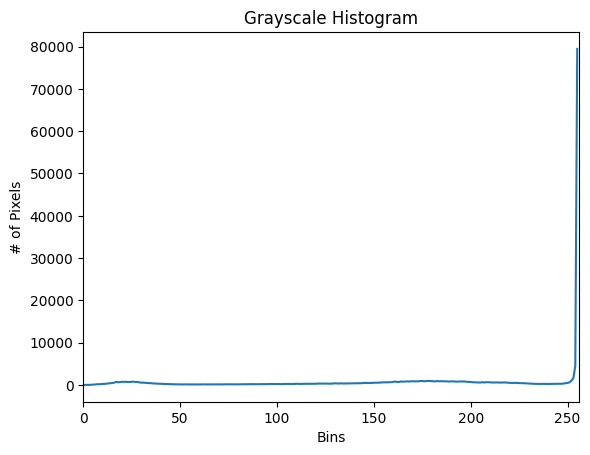

In [11]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure()
plt.title("Grayscale Histogram")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")
plt.plot(hist)
plt.xlim([0, 256])
plt.show()

## Simple Thresholding

`cv2.threshold` with a manually chosen constant threshold value `T`. Every pixel below `T` becomes the object (foreground) and every pixel above `T` becomes background (since the background is *lighter* here we use `THRESH_BINARY_INV`).

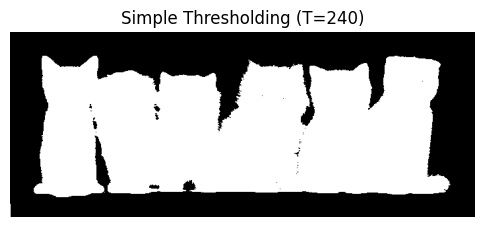

In [12]:
T = 240  # manually chosen threshold, tweak based on the histogram above
_, th_simple = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(6,6))
plt.imshow(th_simple, cmap='gray')
plt.title(f"Simple Thresholding (T={T})")
plt.axis("off")
plt.show()


In [13]:
foreground_simple = cv2.bitwise_and(gray, gray, mask = th_simple)
cv2.imshow("Foreground extraction", np.hstack([gray, th_simple, foreground_simple]))
cv2.waitKey(0)

-1

## Otsu's Thresholding

Otsu's method automatically computes the optimal global threshold by minimizing intra-class variance — no need to guess `T` manually. Works well when the histogram is roughly bimodal (background vs. objects).

Otsu computed threshold: 153.0


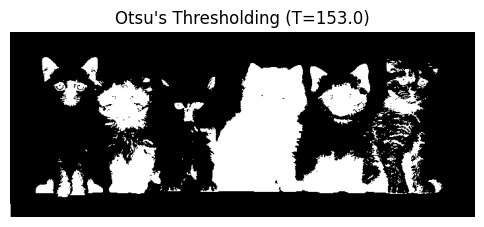

In [14]:
otsu_T, th_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Otsu computed threshold: {otsu_T}")

plt.figure(figsize=(6,6))
plt.imshow(th_otsu, cmap='gray')
plt.title(f"Otsu's Thresholding (T={otsu_T:.1f})")
plt.axis("off")
plt.show()


In [15]:
foreground_otsu = cv2.bitwise_and(gray, gray, mask = th_otsu)
cv2.imshow("Foreground extraction", np.hstack([gray, th_otsu, foreground_otsu]))
cv2.waitKey(0)

-1

## 4. Adaptive Thresholding

Instead of one global threshold, adaptive thresholding computes a threshold for each pixel based on a local neighborhood. Useful when lighting is uneven across the image (e.g. shadows, vignette).

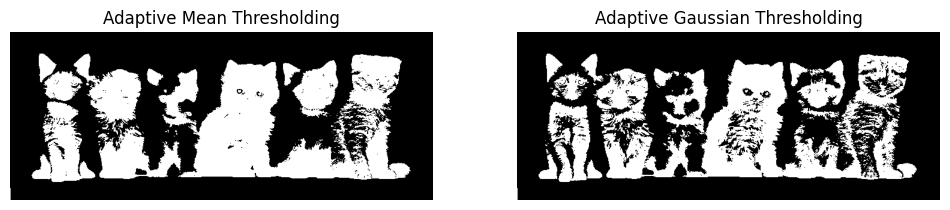

In [16]:
blockSize = 101   # size of the local neighborhood (must be odd)
C = 1            # constant subtracted from the local mean/weighted mean

th_adapt_mean = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY_INV, blockSize, C)

th_adapt_gauss = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY_INV, blockSize, C)

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(th_adapt_mean, cmap='gray'); axes[0].set_title("Adaptive Mean Thresholding"); axes[0].axis("off")
axes[1].imshow(th_adapt_gauss, cmap='gray'); axes[1].set_title("Adaptive Gaussian Thresholding"); axes[1].axis("off")
plt.show()


In [17]:
foreground_adap_mean = cv2.bitwise_and(gray, gray, mask = th_adapt_mean)
cv2.imshow("Foreground extraction", np.hstack([gray, th_adapt_mean, foreground_adap_mean]))
cv2.waitKey(0)

-1

In [18]:
foreground_adap_gauss = cv2.bitwise_and(gray, gray, mask = th_adapt_gauss)
cv2.imshow("Foreground extraction", np.hstack([gray, th_adapt_gauss, foreground_adap_gauss]))
cv2.waitKey(0)

-1

## 5. Clean-up with Morphological Operations

Thresholded masks often contain small noise specks or holes. We use morphological opening (erosion+dilation) and closing (dilation+erosion) to clean the mask before extracting the object.

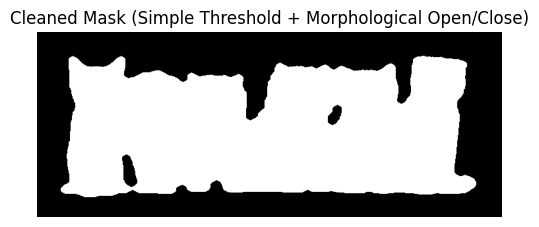

In [19]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))

mask_clean = cv2.morphologyEx(th_simple, cv2.MORPH_OPEN, kernel, iterations=2)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.figure(figsize=(6,6))
plt.imshow(mask_clean, cmap='gray')
plt.title("Cleaned Mask (Simple Threshold + Morphological Open/Close)")
plt.axis("off")
plt.show()


In [21]:
foreground_clean = cv2.bitwise_and(gray, gray, mask = mask_clean)
cv2.imshow("Foreground extraction", np.hstack([gray, mask_clean, foreground_clean]))
cv2.waitKey(0)

-1

## 6. Extract the Objects (Apply Mask to Original Image)

Using the cleaned binary mask, we extract just the object pixels from the original color image and place them onto a transparent/white background.

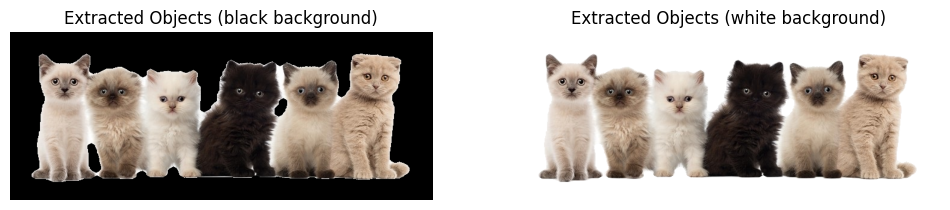

Saved: extracted_objects_black_bg.png, extracted_objects_white_bg.png


In [22]:
# Extracted objects on black background
extracted_black = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_clean)

# Extracted objects on white background (mask inverted where background)
white_bg = np.full_like(img_bgr, 255)
extracted_white = np.where(mask_clean[...,None].astype(bool), img_bgr, white_bg)

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(cv2.cvtColor(extracted_black, cv2.COLOR_BGR2RGB))
axes[0].set_title("Extracted Objects (black background)")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(extracted_white, cv2.COLOR_BGR2RGB))
axes[1].set_title("Extracted Objects (white background)")
axes[1].axis("off")
plt.show()

cv2.imwrite("extracted_objects_black_bg.png", extracted_black)
cv2.imwrite("extracted_objects_white_bg.png", extracted_white)
print("Saved: extracted_objects_black_bg.png, extracted_objects_white_bg.png")


## 7. Side-by-Side Comparison of All Thresholding Techniques

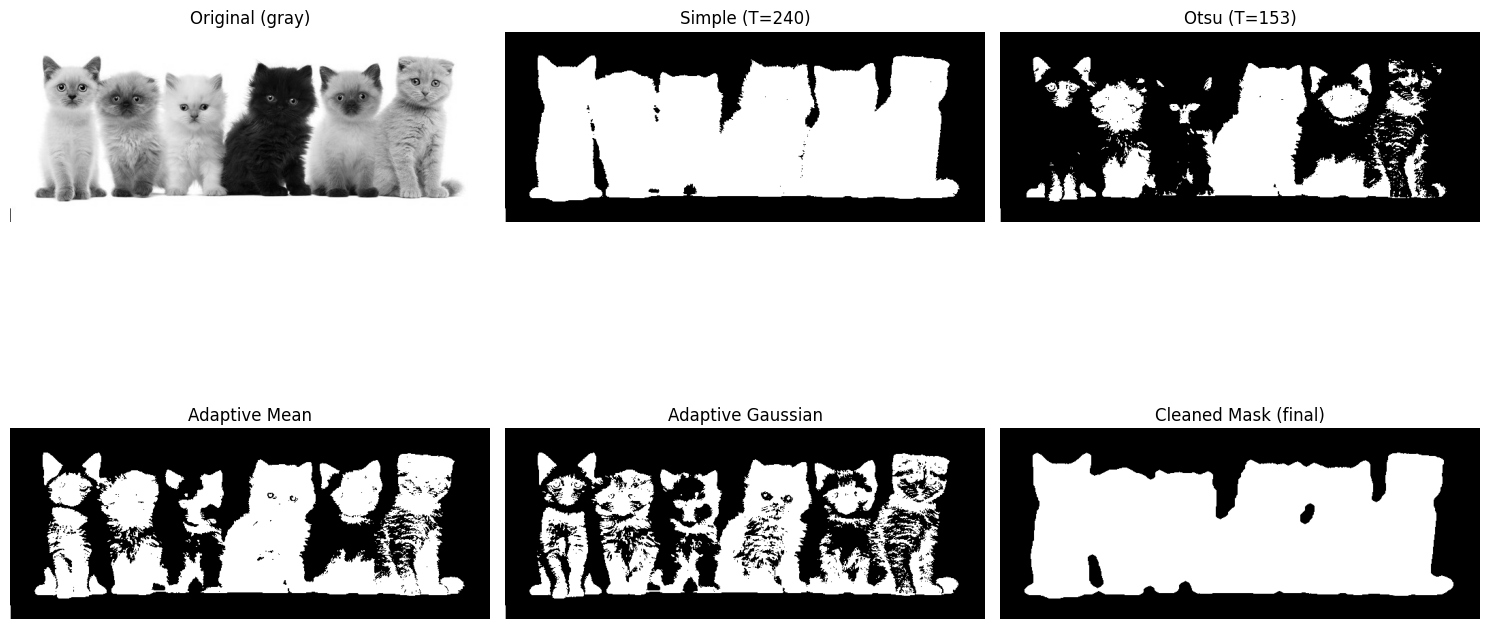

Saved comparison figure: thresholding_comparison.png


In [24]:
titles = ["Original (gray)", f"Simple (T={T})", f"Otsu (T={otsu_T:.0f})",
          "Adaptive Mean", "Adaptive Gaussian", "Cleaned Mask (final)"]
images = [gray, th_simple, th_otsu, th_adapt_mean, th_adapt_gauss, mask_clean]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
for ax, title, im in zip(axes.ravel(), titles, images):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig("thresholding_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved comparison figure: thresholding_comparison.png")


## Conclusion
On this real photo, the automatic methods surprisingly underperformed a manually-tuned threshold — an important practical lesson.

- **Simple thresholding (T=240)** produced the cleanest, most complete silhouette of all the kittens, despite being manually tuned. The reason: the background here is nearly pure white (~250–255), and even the lightest kitten's fur is noticeably darker than that level. By setting the threshold close to white, we cut out the background while keeping the objects intact, regardless of their internal brightness variation.

- **Otsu (T=153)** performed noticeably worse, even though it's usually expected to be "optimal." Otsu minimizes inter-class variance across the whole histogram and lands on a threshold somewhere in the middle of the brightness range — but here, fur brightness is spread across almost the entire scale (from the black kitten to pale cream-colored ones), rather than clustered into one clearly "dark" group. As a result, the threshold of 153 ended up slicing through the fur itself into light/dark patches instead of marking the cat/background boundary — visible as the "torn," hole-riddled mask inside each kitten.

- **Adaptive Mean / Adaptive Gaussian** emphasized fur texture (stripes, patches, facial contours) even more strongly, because adaptive thresholding reacts to local contrast rather than the global object-vs-background difference. Since the lighting here is even (no shadows or highlights, which adaptive thresholding is normally meant to compensate for), the method only added noise instead of helping.

- **Cleaned Mask** (morphology applied after Otsu) smoothed the edges somewhat, but couldn't fix the underlying problem — since the mask was built on flawed internal splits from the start, the best it could achieve was a rough rectangular silhouette with holes, not clean boundaries around individual kittens.

**Key takeaway**: Otsu and adaptive thresholding are not universally "best" methods — they're only optimal under specific conditions (a clearly bimodal histogram for Otsu; uneven lighting for adaptive). When the object itself spans a wide brightness range (dark and light fur in the same scene) and the background is significantly lighter/darker than the entire object range, a manually chosen threshold placed right at the background's edge can outperform automatic methods.

**Additional limitation**: even the best mask (Simple, T=240) still merges all the kittens into a single connected blob, since they physically touch each other in the photo — no thresholding technique can fix this. Separating individual kittens requires watershed segmentation (distance transform + local maxima), not thresholding alone.